# Introduction
#### This notebook shows my work on the famous fashion MINST data set, I tried to build a classifier using two algorithms: Support Vector Machine SVM and Convolutional Neural Network CNN to classify clothes into 10 classes or types: T-shirt/top, Trouser, Pullover, Dress, Coat, Sandal, Shirt, Sneaker, Bag, Ankle boot.
#### The results of two algorithms are then compared to know which one preformed better and had higher accuracy. This is presented using confusion matrix for each model.

### Import libraries

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
from keras.models import Sequential
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from tensorflow.keras import layers

# Import and Visulaize Data

In [3]:
#read the train dataset, then split the features and labels
train_set = pd.read_csv("/kaggle/input/fashionmnist/fashion-mnist_train.csv")
x_train = train_set.iloc[:,1:]
y_train = train_set.iloc[:,0]
print(x_train.head(5))
print(y_train.head())

   pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       5       0   
3       0       0       0       1       2       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel10  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0        0  ...         0         0         0         0         0         0   
1        0  ...         0         0         0         0         0         0   
2        0  ...         0         0         0        30        43         0   
3        0  ...         3         0         0         0         0         1   
4        0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0       

In [4]:
#read the test dataset, then split the features and labels
test_set = pd.read_csv("/kaggle/input/fashionmnist/fashion-mnist_train.csv")
x_test = test_set.iloc[:,1:]
y_test = test_set.iloc[:,:1]
print(x_test.head(5))
print(y_test.head())

   pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       5       0   
3       0       0       0       1       2       0       0       0       0   
4       0       0       0       0       0       0       0       0       0   

   pixel10  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0        0  ...         0         0         0         0         0         0   
1        0  ...         0         0         0         0         0         0   
2        0  ...         0         0         0        30        43         0   
3        0  ...         3         0         0         0         0         1   
4        0  ...         0         0         0         0         0         0   

   pixel781  pixel782  pixel783  pixel784  
0         0       

/tmp/ipykernel_32/2868825510.py:7: UserWarning: FixedFormatter should only be used together with FixedLocator
  bar.set_xticklabels(labels, rotation = 45)


[Text(0, 0, 'T-shirt/top'),
 Text(1, 0, 'Trouser'),
 Text(2, 0, 'Pullover'),
 Text(3, 0, 'Dress'),
 Text(4, 0, 'Coat'),
 Text(5, 0, 'Sandal'),
 Text(6, 0, 'Shirt'),
 Text(7, 0, 'Sneaker'),
 Text(8, 0, 'Bag'),
 Text(9, 0, 'Ankle boot')]

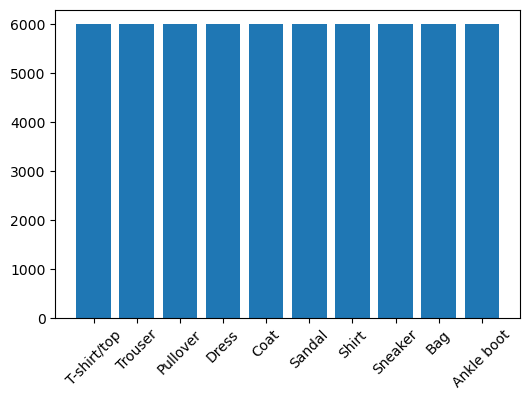

In [5]:
#Visualize the classes
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat','Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
uni = np.unique(np.array(y_test), return_counts=True)
fig = plt.figure(figsize = (6,4))
bar = fig.add_subplot(111)
bar.bar(labels,uni[1])
bar.set_xticklabels(labels, rotation = 45)

# Support Vector Machine - SVM

In [6]:
#train support vector machine model, and print it accuracy
model = svm.SVC()

model.fit(x_train,y_train)

acc = model.score(x_test,y_test)
print('Model Accuracy: ',acc)

Model Accuracy:  0.91105


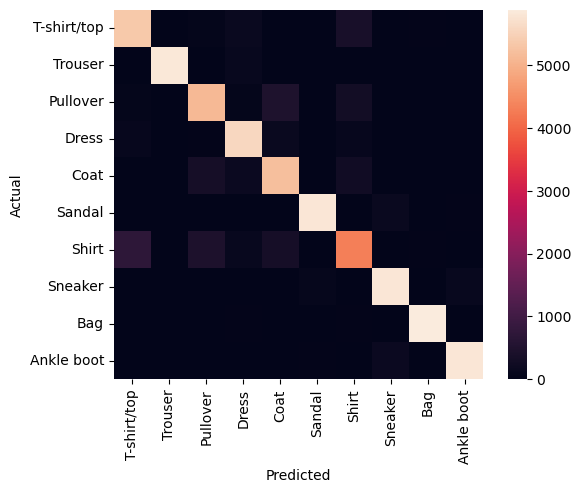

In [7]:
#confusion matrix of svm model on test set
y_pred = model.predict(x_test)
cm = confusion_matrix(y_test,y_pred)
df_cm = pd.DataFrame(cm, labels, labels)
sns.heatmap(df_cm, square = True)
plt.xlabel("Predicted") 
plt.ylabel("Actual")
plt.show()

# Convolutional Neural Network

In [8]:
#Encoding the values of y for cnn model 
y_train1 = np.array(y_train).reshape(-1,1)
y_test1 = np.array(y_test).reshape(-1,1)
enc = OneHotEncoder()  
enc.fit(y_train1)
y_train1 = enc.transform(y_train1).toarray()
y_test1 = enc.transform(y_test1).toarray()
y_train1.shape

(60000, 10)

In [ ]:
#reshape features
X_train=np.array(x_train).reshape(x_train.shape[0],28,28,1)

X_test=np.array(x_test).reshape(x_test.shape[0],28,28,1)

In [10]:
#Create convolutional neural network, cnn
model = Sequential()
model.add(layers.Conv2D(64, kernel_size=3, activation='relu',input_shape=X_train.shape[1:]))
model.add(layers.Conv2D(32, kernel_size=3, activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(10, activation='softmax'))

model.compile(loss = 'categorical_crossentropy', optimizer = 'adam', metrics = ['accuracy'])
history = model.fit(X_train, y_train1, validation_split=0.33, epochs=10,batch_size=10)

Epoch 1/10
4020/4020 [==============================] - 89s 22ms/step - loss: 0.5989 - accuracy: 0.8131 - val_loss: 0.4169 - val_accuracy: 0.8558
Epoch 2/10
4020/4020 [==============================] - 89s 22ms/step - loss: 0.3773 - accuracy: 0.8635 - val_loss: 0.3772 - val_accuracy: 0.8672
Epoch 3/10
4020/4020 [==============================] - 88s 22ms/step - loss: 0.3179 - accuracy: 0.8824 - val_loss: 0.3779 - val_accuracy: 0.8713
Epoch 4/10
4020/4020 [==============================] - 87s 22ms/step - loss: 0.2706 - accuracy: 0.8984 - val_loss: 0.4008 - val_accuracy: 0.8715
Epoch 5/10
4020/4020 [==============================] - 87s 22ms/step - loss: 0.2359 - accuracy: 0.9110 - val_loss: 0.4442 - val_accuracy: 0.8712
Epoch 6/10
4020/4020 [==============================] - 87s 22ms/step - loss: 0.2129 - accuracy: 0.9211 - val_loss: 0.4864 - val_accuracy: 0.8658
Epoch 7/10
4020/4020 [==============================] - 86s 21ms/step - loss: 0.1915 - accuracy: 0.9291 - val_loss: 0.5165 -

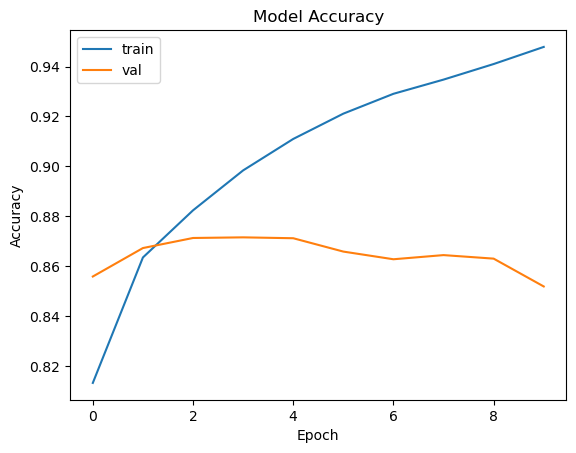

In [11]:
#Plot train and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [12]:
#loss and accuracy of the cnn model on test set
model.evaluate(X_test, y_test1)

1875/1875 [==============================] - 21s 11ms/step - loss: 0.3192 - accuracy: 0.9162


[0.31923460960388184, 0.9162333607673645]

1875/1875 [==============================] - 21s 11ms/step


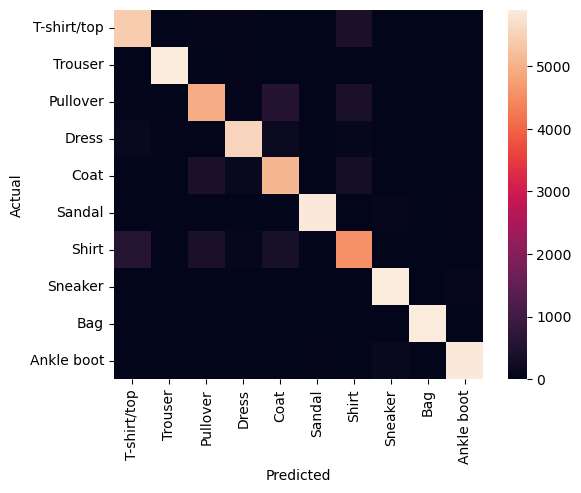

In [13]:
#Prediction and Decode the results
y_pred = model.predict(X_test)
y_pred2 = np.zeros((y_pred.shape[0],1))
for i in range(y_pred.shape[0]):
    y_pred2[i] = y_pred[i].argmax()
    
#Confusion matrix of cnn model on test set
cm = confusion_matrix(y_test,y_pred2)
df_cm = pd.DataFrame(cm, labels, labels)
sns.heatmap(df_cm, square = True)
plt.xlabel("Predicted") 
plt.ylabel("Actual")
plt.show()

### **This is the end of my work. I would love to hear your thoughts and any feedback you may have. Thank you!**